In [158]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

In [159]:
data = pd.read_csv('water_potability.csv')
data.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


# EDA

In [160]:
data.shape

(3276, 10)

In [161]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [162]:
data.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


### Checking Imbalance Data

In [163]:
data.Potability

0       0
1       0
2       0
3       0
4       0
       ..
3271    1
3272    1
3273    1
3274    1
3275    1
Name: Potability, Length: 3276, dtype: int64

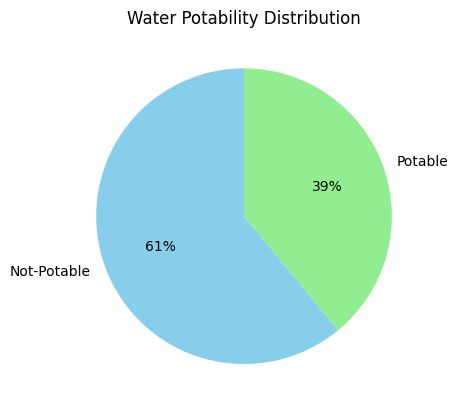

In [164]:
plt.pie(data.Potability.value_counts(), labels=data.Potability.value_counts().rename(index={0:'Not-Potable', 1:'Potable'}).index, autopct='%1.0f%%', startangle=90, colors=['skyblue', 'lightgreen'])
plt.title('Water Potability Distribution')
plt.show()

### Missing Data

In [165]:
data.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [166]:
data.isnull().mean()*100

ph                 14.987790
Hardness            0.000000
Solids              0.000000
Chloramines         0.000000
Sulfate            23.840049
Conductivity        0.000000
Organic_carbon      0.000000
Trihalomethanes     4.945055
Turbidity           0.000000
Potability          0.000000
dtype: float64

ph
Mean: 7.080794504276835
Median: 7.036752103833548


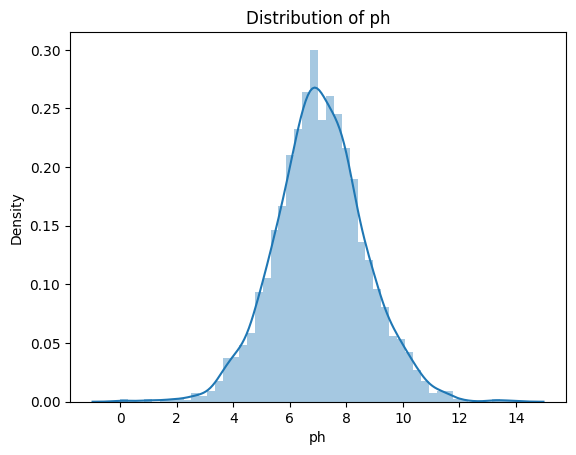

Sulfate
Mean: 333.7757766108135
Median: 333.073545745888


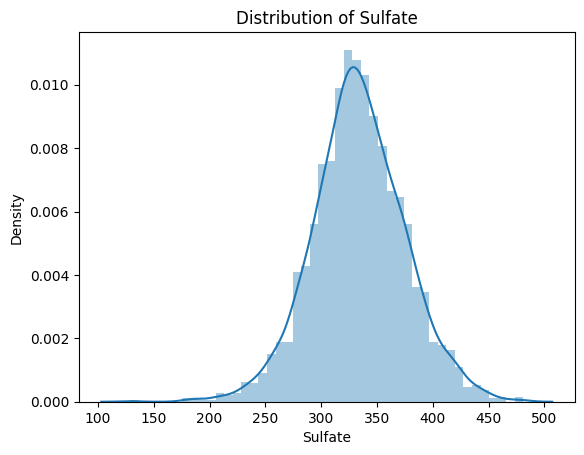

Trihalomethanes
Mean: 66.39629294676803
Median: 66.62248509808484


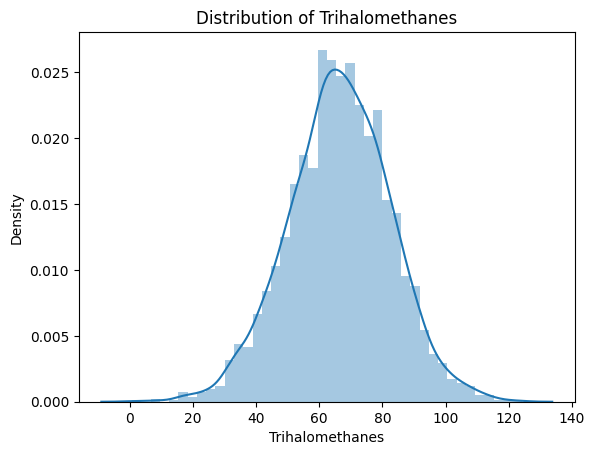

In [167]:
for i in data.columns:
    if data[i].isnull().sum() > 0:
        print(i)
        print("Mean:", data[i].mean())
        print("Median:", data[i].median())
        sns.distplot(data[i])
        plt.title(f"Distribution of {i}")
        plt.show()

In [168]:
for i in data.columns:
    if data[i].isnull().sum() > 0:
        data[i].fillna(data[i].mean(), inplace=True)

In [169]:
data.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

### Duplicate Data

In [170]:
data[data.duplicated()]

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability


### Outliers Detection

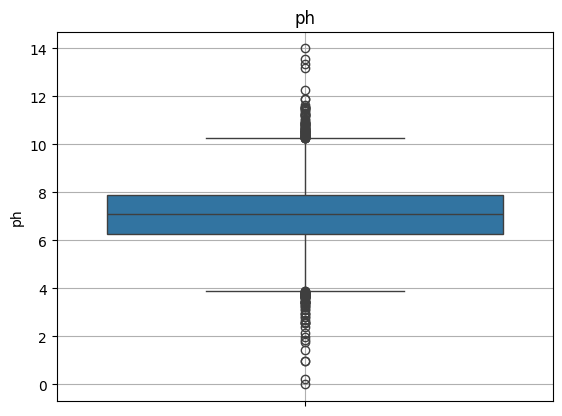

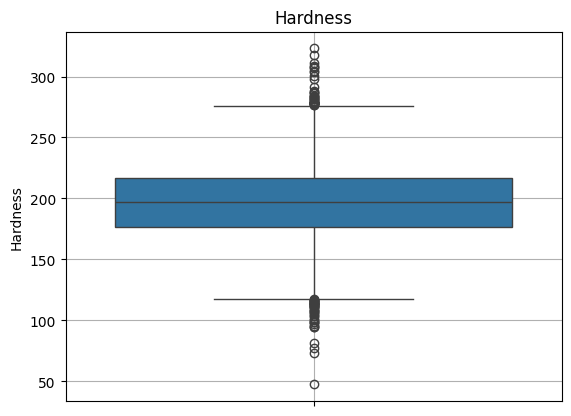

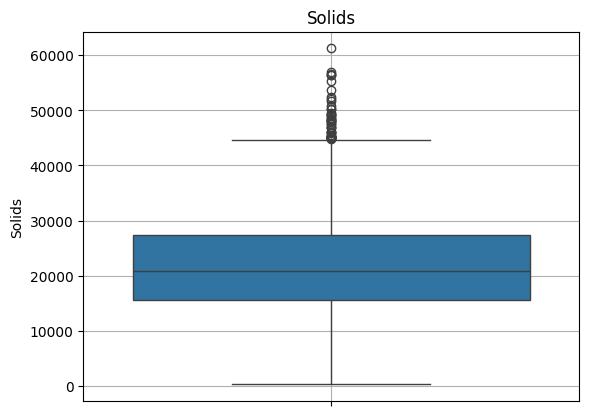

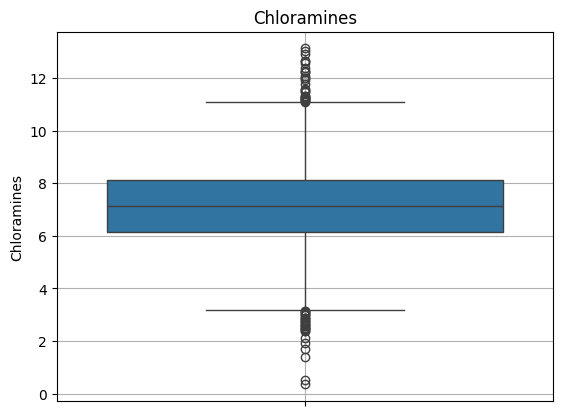

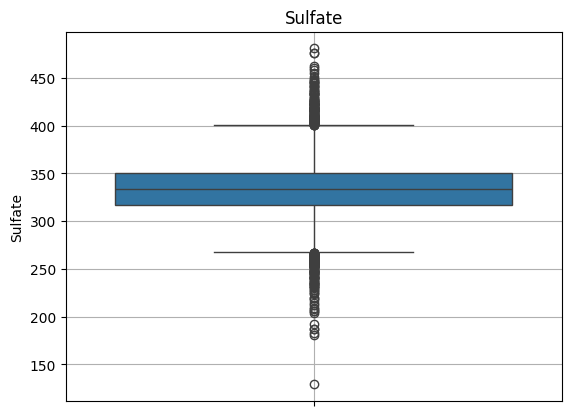

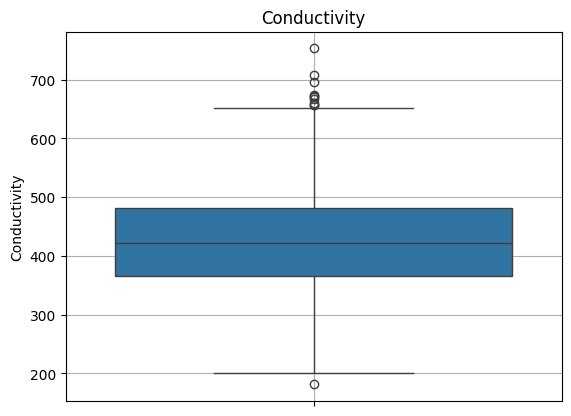

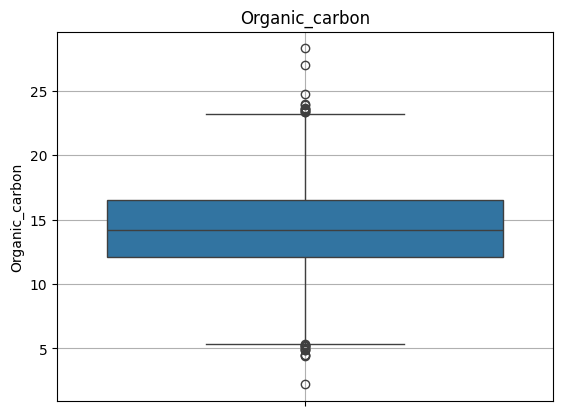

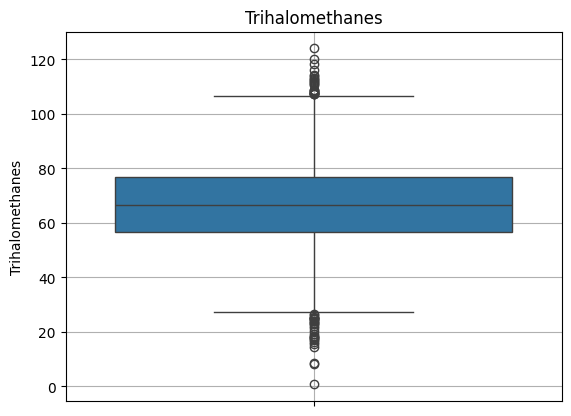

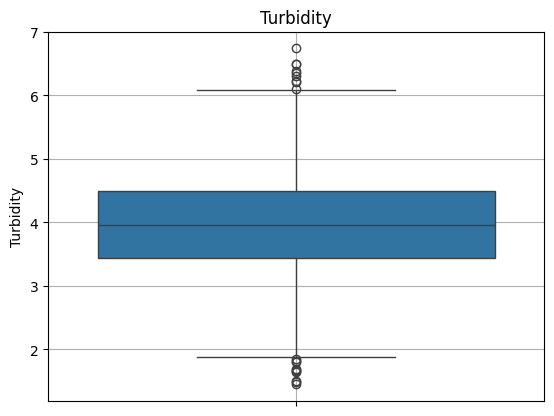

In [171]:
for i in data.columns:
    if i == "Potability": continue
    sns.boxplot(data[i])
    plt.title(i)
    plt.grid()
    plt.show()

In [172]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

In [173]:
data = data[~((data < lower_bound) | (data > upper_bound)).any(axis=1)]

In [174]:
data.shape

(2666, 10)

### Feature Selection

In [175]:
data.corr()['Potability']

ph                -0.005949
Hardness          -0.000710
Solids             0.005600
Chloramines        0.013195
Sulfate           -0.003741
Conductivity      -0.001886
Organic_carbon    -0.027090
Trihalomethanes    0.014351
Turbidity          0.004761
Potability         1.000000
Name: Potability, dtype: float64

# Model Building

In [176]:
data.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0


In [177]:
data.shape

(2666, 10)

### Separate Independent/Dependent Data

In [178]:
x = data.drop('Potability', axis=1)
y = data.Potability

### Train/Test Split

In [179]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### Feature Scalling

In [180]:
sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

# Model Selection

### Logistic Regression

In [181]:
lr = LogisticRegression()
lr.fit(x_train_sc, y_train)

LogisticRegression()

In [182]:
print(f"Training Accuracy: {round(lr.score(x_train_sc, y_train), 2)*100} %")
print(f"Test Accuracy: {round(lr.score(x_test_sc, y_test), 2)*100} %")

Training Accuracy: 62.0 %
Test Accuracy: 64.0 %


### Decision Tree

In [183]:
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(x_train_sc, y_train)

DecisionTreeClassifier(max_depth=5)

In [184]:
print(f"Training Accuracy: {round(dt.score(x_train_sc, y_train), 2)*100} %")
print(f"Test Accuracy: {round(dt.score(x_test_sc, y_test), 2)*100} %")

Training Accuracy: 70.0 %
Test Accuracy: 63.0 %


### Gradient Boosting

In [185]:
gb = GradientBoostingClassifier()
gb.fit(x_train_sc, y_train)

GradientBoostingClassifier()

In [186]:
print(f"Training Accuracy: {round(gb.score(x_train_sc, y_train), 2)*100} %")
print(f"Test Accuracy: {round(gb.score(x_test_sc, y_test), 2)*100} %")

Training Accuracy: 75.0 %
Test Accuracy: 64.0 %


# Model Training - Gradient Boosting

In [187]:
model = GradientBoostingClassifier()
model.fit(x_train_sc, y_train)

GradientBoostingClassifier()

# Model Prediction

In [188]:
y_train_pred = model.predict(x_train_sc)
y_test_pred = model.predict(x_test_sc)

# Model Evaluation

### Training Data

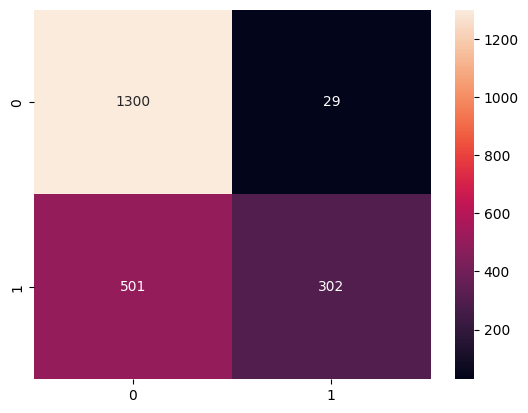

In [195]:
sns.heatmap(confusion_matrix(y_train, y_train_pred), annot=True, fmt='.4g')
plt.show()

In [196]:
accuracy_score(y_train, y_train_pred)

0.7514071294559099

In [197]:
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       0.72      0.98      0.83      1329
           1       0.91      0.38      0.53       803

    accuracy                           0.75      2132
   macro avg       0.82      0.68      0.68      2132
weighted avg       0.79      0.75      0.72      2132



### Test Data

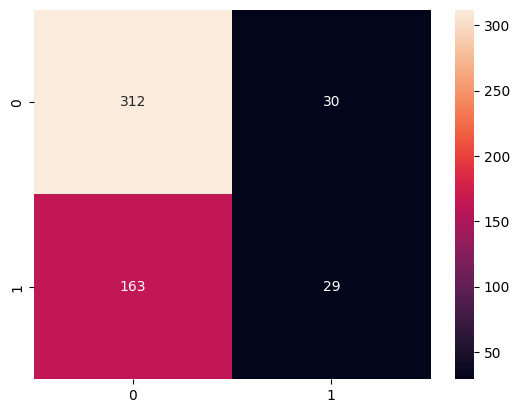

In [199]:
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='.4g')
plt.show()

In [200]:
accuracy_score(y_test, y_test_pred)

0.6385767790262172

In [201]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.66      0.91      0.76       342
           1       0.49      0.15      0.23       192

    accuracy                           0.64       534
   macro avg       0.57      0.53      0.50       534
weighted avg       0.60      0.64      0.57       534

